In [2]:
from google.colab import files
uploaded = files.upload()


Saving tayseer_services.csv to tayseer_services.csv


In [4]:
import pandas as pd

df = pd.read_csv("tayseer_services.csv")

display(df.head())
print("Rows and columns:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.info()

display(df.isna().sum().rename("Missing values"))

,month,region,service_category,channel,transactions,unique_users,digital_adoption_pct,avg_completion_min,cost_per_txn_sar,csat,sla_met_pct,complaints
0,2021-07-01,Al-Baha,Business & Licensing,Branch,5727,4745,33.4,117.0,51.88,3.05,80.7,10
1,2021-07-01,Al-Baha,Business & Licensing,Call Center,2575,1708,33.4,31.5,24.11,3.57,93.2,2
2,2021-07-01,Al-Baha,Business & Licensing,Mobile App,1936,721,33.4,13.7,6.26,4.13,96.2,1
3,2021-07-01,Al-Baha,Business & Licensing,Web Portal,2425,1221,33.4,19.4,8.63,3.85,94.9,3
4,2021-07-01,Al-Baha,Education & Training,Branch,7443,5923,37.0,29.4,39.00,3.55,84.4,7


Rows and columns: (28080, 12)

Column names: ['month', 'region', 'service_category', 'channel', 'transactions', 'unique_users', 'digital_adoption_pct', 'avg_completion_min', 'cost_per_txn_sar', 'csat', 'sla_met_pct', 'complaints']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28080 entries, 0 to 28079
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   month                 28080 non-null  object 
 1   region                28080 non-null  object 
 2   service_category      28080 non-null  object 
 3   channel               28080 non-null  object 
 4   transactions          28080 non-null  int64  
 5   unique_users          28080 non-null  int64  
 6   digital_adoption_pct  28080 non-null  float64
 7   avg_completion_min    28080 non-null  float64
 8   cost_per_txn_sar      28080 non-null  float64
 9   csat                  28080 non-null  float64
 10  sla_met_pct           28080 non-null  float

,Missing values
month,0
region,0
service_category,0
channel,0
transactions,0
unique_users,0
digital_adoption_pct,0
avg_completion_min,0
cost_per_txn_sar,0
csat,0


In [5]:
# Convert the month column to dates
df["month"] = pd.to_datetime(df["month"])

# Inspect coverage
print("Period:", df["month"].min().date(),
      "to", df["month"].max().date())
print("Number of months:", df["month"].nunique())

for column in ["region", "service_category", "channel"]:
    print(f"\n{column}:")
    print(sorted(df[column].unique()))

# Each combination should identify one row
keys = ["month", "region", "service_category", "channel"]
print("\nDuplicate month–region–category–channel records:",
      df.duplicated(subset=keys).sum())

print("Rows with zero or negative transactions:",
      (df["transactions"] <= 0).sum())

Period: 2021-07-01 to 2026-06-01
Number of months: 60

region:
['Al-Baha', 'Al-Jouf', 'Asir', 'Eastern Province', 'Hail', 'Jazan', 'Madinah', 'Makkah', 'Najran', 'Northern Borders', 'Qassim', 'Riyadh', 'Tabuk']

service_category:
['Business & Licensing', 'Education & Training', 'Health Services', 'Identity & Civil Affairs', 'Justice & Notary', 'Labour & HR Services', 'Municipal Services', 'Social Support & Subsidies', 'Traffic & Transport']

channel:
['Branch', 'Call Center', 'Mobile App', 'Web Portal']

Duplicate month–region–category–channel records: 0
Rows with zero or negative transactions: 0


In [6]:
# Select the latest 12 months of branch services
end_month = df["month"].max()
start_month = end_month - pd.DateOffset(months=11)

branch = df.loc[
    df["channel"].eq("Branch")
    & df["month"].between(start_month, end_month)
].copy()

# Weight each row's average completion time by its transactions
branch["weighted_minutes"] = (
    branch["avg_completion_min"] * branch["transactions"]
)

category_summary = (
    branch.groupby("service_category", as_index=False)
    .agg(
        transactions=("transactions", "sum"),
        weighted_minutes=("weighted_minutes", "sum")
    )
)

category_summary["completion_min"] = (
    category_summary["weighted_minutes"]
    / category_summary["transactions"]
)

category_summary = category_summary.sort_values(
    "completion_min", ascending=False
)

print(
    f"Branch services: {start_month:%B %Y}–{end_month:%B %Y}"
)

display(
    category_summary[[
        "service_category", "transactions", "completion_min"
    ]].round({"completion_min": 2})
)

Branch services: July 2025–June 2026


,service_category,transactions,completion_min
4,Justice & Notary,1893582,81.31
0,Business & Licensing,2784186,73.64
6,Municipal Services,3363601,32.62
7,Social Support & Subsidies,2473377,31.46
3,Identity & Civil Affairs,4618016,29.15
5,Labour & HR Services,2927933,28.89
2,Health Services,4491490,25.74
8,Traffic & Transport,4217947,24.25
1,Education & Training,3428726,22.62


In [7]:
# Calculate monthly weighted completion times for each category
monthly = (
    branch.groupby(["month", "service_category"], as_index=False)
    .agg(
        transactions=("transactions", "sum"),
        weighted_minutes=("weighted_minutes", "sum")
    )
)

monthly["completion_min"] = (
    monthly["weighted_minutes"] / monthly["transactions"]
)

# Compare the two categories with the longest annual averages
top_two = category_summary.head(2)["service_category"].tolist()

monthly_comparison = (
    monthly.loc[monthly["service_category"].isin(top_two)]
    .pivot(
        index="month",
        columns="service_category",
        values="completion_min"
    )
    .sort_index()
)

display(monthly_comparison.round(2))

service_category,Business & Licensing,Justice & Notary
month,,
2025-07-01,65.69,82.37
2025-08-01,75.75,74.35
2025-09-01,80.77,82.96
2025-10-01,76.71,80.86
2025-11-01,80.94,85.78
2025-12-01,69.97,88.32
2026-01-01,80.61,78.28
2026-02-01,69.10,79.57
2026-03-01,69.72,91.16


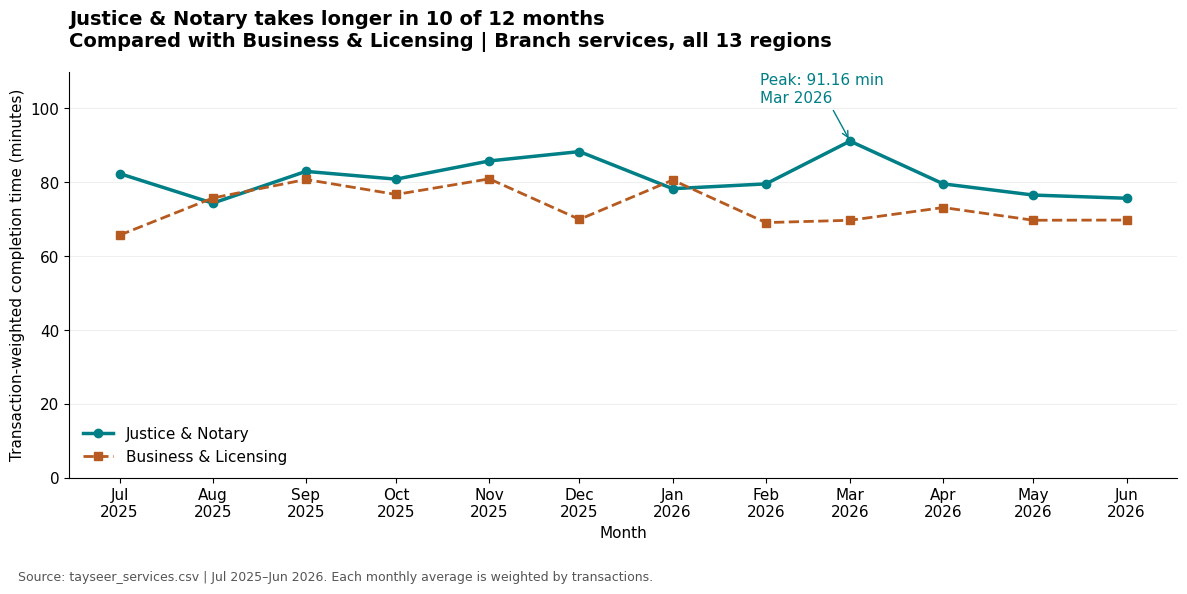

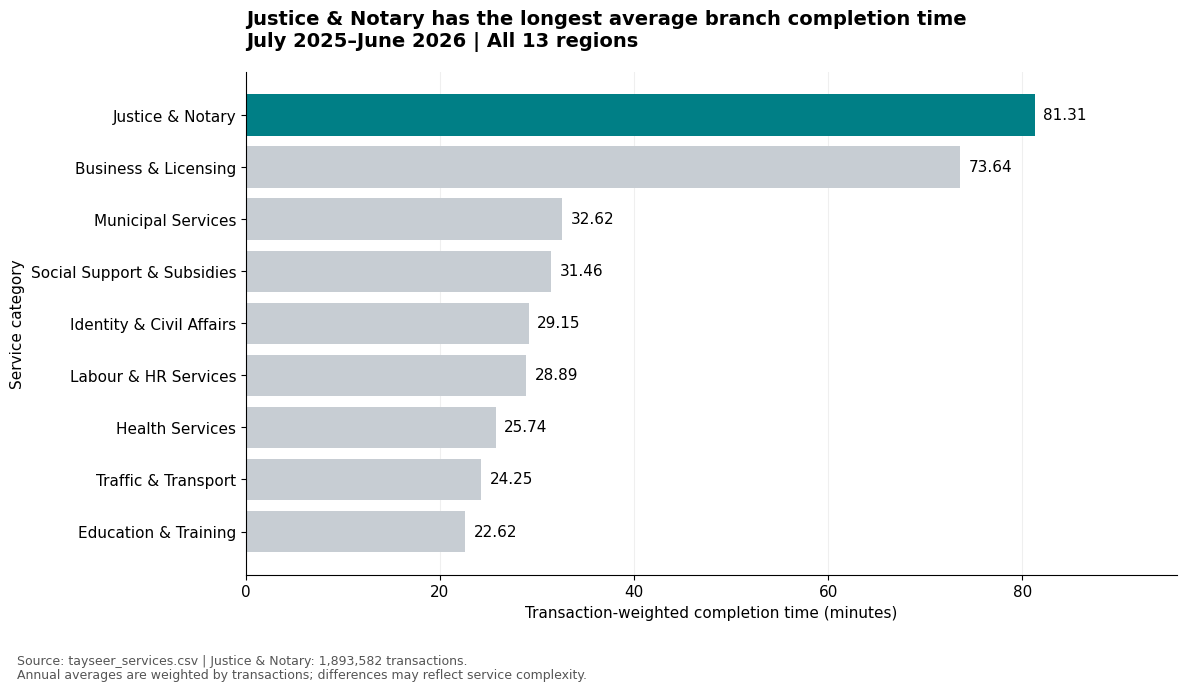

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

Path("charts").mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

highlight = "#007F86"
comparison = "#B65A20"
neutral = "#C7CDD3"

# CHART 1: Monthly change
justice = monthly_comparison["Justice & Notary"]
business = monthly_comparison["Business & Licensing"]
months_higher = int((justice > business).sum())

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    justice.index, justice,
    color=highlight, marker="o", linewidth=2.5,
    label="Justice & Notary"
)
ax.plot(
    business.index, business,
    color=comparison, marker="s", linestyle="--",
    linewidth=2, label="Business & Licensing"
)

peak_month = justice.idxmax()
peak_value = justice.max()

ax.annotate(
    f"Peak: {peak_value:.2f} min\n{peak_month:%b %Y}",
    xy=(peak_month, peak_value),
    xytext=(-65, 28),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": highlight},
    color=highlight
)

ax.set_title(
    f"Justice & Notary takes longer in {months_higher} of 12 months\n"
    "Compared with Business & Licensing | Branch services, all 13 regions",
    loc="left", fontsize=14, fontweight="bold", pad=18
)
ax.set_ylabel("Transaction-weighted completion time (minutes)")
ax.set_xlabel("Month")
ax.set_ylim(0, 110)
ax.set_xticks(monthly_comparison.index)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="lower left", frameon=False)

fig.text(
    0.02, 0.02,
    "Source: tayseer_services.csv | Jul 2025–Jun 2026. "
    "Each monthly average is weighted by transactions.",
    fontsize=9, color="#555555"
)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("charts/monthly_completion.png", dpi=200, bbox_inches="tight")
plt.show()


# CHART 2: Comparison of all nine categories
ranked = category_summary.sort_values(
    "completion_min", ascending=False
)

colors = [
    highlight if category == "Justice & Notary" else neutral
    for category in ranked["service_category"]
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    ranked["service_category"],
    ranked["completion_min"],
    color=colors
)
ax.invert_yaxis()

ax.bar_label(
    bars,
    labels=[f"{value:.2f}" for value in ranked["completion_min"]],
    padding=6
)

ax.set_title(
    "Justice & Notary has the longest average branch completion time\n"
    "July 2025–June 2026 | All 13 regions",
    loc="left", fontsize=14, fontweight="bold", pad=18
)
ax.set_xlabel("Transaction-weighted completion time (minutes)")
ax.set_ylabel("Service category")
ax.set_xlim(0, ranked["completion_min"].max() * 1.18)
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.2)

justice_transactions = int(
    ranked.loc[
        ranked["service_category"].eq("Justice & Notary"),
        "transactions"
    ].iloc[0]
)

fig.text(
    0.02, 0.02,
    f"Source: tayseer_services.csv | Justice & Notary: "
    f"{justice_transactions:,} transactions.\n"
    "Annual averages are weighted by transactions; "
    "differences may reflect service complexity.",
    fontsize=9, color="#555555"
)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("charts/category_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
import plotly.express as px
from pathlib import Path

Path("charts").mkdir(exist_ok=True)

colors = {
    "Justice & Notary": "#007F86",
    "Business & Licensing": "#B65A20"
}

# 1. Interactive monthly line chart
line_data = monthly.loc[
    monthly["service_category"].isin(top_two)
].copy()

fig_line = px.line(
    line_data,
    x="month",
    y="completion_min",
    color="service_category",
    markers=True,
    color_discrete_map=colors,
    custom_data=["transactions"],
    labels={
        "month": "Month",
        "completion_min": "Weighted completion time (minutes)",
        "service_category": "Service category"
    },
    title=(
        "Justice & Notary takes longer in 10 of 12 months"
        "<br><sup>Compared with Business & Licensing | "
        "Branch services, all 13 regions | Jul 2025–Jun 2026</sup>"
    ),
    template="plotly_white"
)

fig_line.update_traces(
    hovertemplate=(
        "%{x|%b %Y}<br>"
        "Completion time: %{y:.2f} minutes<br>"
        "Transactions: %{customdata[0]:,.0f}"
        "<extra>%{fullData.name}</extra>"
    )
)

peak = line_data.loc[
    line_data["service_category"].eq("Justice & Notary")
].sort_values("completion_min").iloc[-1]

fig_line.add_annotation(
    x=peak["month"],
    y=peak["completion_min"],
    text=f"Peak: {peak['completion_min']:.2f} min",
    showarrow=True,
    arrowhead=2,
    ax=-65,
    ay=-40
)

fig_line.update_layout(
    height=550,
    hovermode="x unified",
    legend=dict(
        title="",
        orientation="h",
        y=1.02,
        x=0
    ),
    margin=dict(t=140, b=100),
    yaxis=dict(range=[0, 110]),
    xaxis=dict(
        tickformat="%b<br>%Y",
        dtick="M1"
    )
)

fig_line.add_annotation(
    x=0, y=-0.23,
    xref="paper", yref="paper",
    text="Source: tayseer_services.csv | Monthly averages weighted by transactions.",
    showarrow=False,
    xanchor="left",
    font=dict(size=11, color="#555555")
)

fig_line.show(config={"displaylogo": False})
fig_line.write_html(
    "charts/monthly_completion_interactive.html",
    include_plotlyjs=True
)


# 2. Interactive category comparison
bar_data = category_summary.sort_values(
    "completion_min", ascending=False
).copy()

fig_bar = px.bar(
    bar_data,
    x="completion_min",
    y="service_category",
    orientation="h",
    text="completion_min",
    custom_data=["transactions"],
    labels={
        "completion_min": "Weighted completion time (minutes)",
        "service_category": "Service category"
    },
    title=(
        "Justice & Notary has the longest average branch completion time"
        "<br><sup>All 13 regions | July 2025–June 2026</sup>"
    ),
    template="plotly_white"
)

fig_bar.update_traces(
    marker_color=[
        "#007F86" if category == "Justice & Notary" else "#C7CDD3"
        for category in bar_data["service_category"]
    ],
    texttemplate="%{x:.2f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "%{y}<br>"
        "Completion time: %{x:.2f} minutes<br>"
        "Transactions: %{customdata[0]:,.0f}"
        "<extra></extra>"
    )
)

fig_bar.update_layout(
    height=650,
    margin=dict(l=210, r=70, t=110, b=110),
    yaxis=dict(
        categoryorder="array",
        categoryarray=bar_data["service_category"].tolist(),
        autorange="reversed"
    ),
    xaxis=dict(range=[0, bar_data["completion_min"].max() * 1.2])
)

fig_bar.add_annotation(
    x=0, y=-0.20,
    xref="paper", yref="paper",
    text=(
        "Source: tayseer_services.csv | Weighted by transactions."
        "<br>Longer completion times may reflect service complexity."
    ),
    showarrow=False,
    xanchor="left",
    font=dict(size=11, color="#555555")
)

fig_bar.show(config={"displaylogo": False})
fig_bar.write_html(
    "charts/category_comparison_interactive.html",
    include_plotlyjs=True
)
# Move the peak label below and to the left of the point
fig_line.layout.annotations[0].update(
    ax=-65,
    ay=45,
    bgcolor="white",
    borderpad=4
)



layout.Annotation({
    'arrowhead': 2,
    'ax': -65,
    'ay': 45,
    'bgcolor': 'white',
    'borderpad': 4,
    'showarrow': True,
    'text': 'Peak: 91.16 min',
    'x': Timestamp('2026-03-01 00:00:00'),
    'y': np.float64(91.15507449172772)
})

In [14]:
fig_line.layout.annotations[0].update(
    ax=65,
    ay=-15,
    bgcolor="white",
    borderpad=4
)

fig_line.show(renderer="colab")

fig_line.write_html(
    "charts/monthly_completion_interactive.html",
    include_plotlyjs=True
)